<a href="https://colab.research.google.com/github/duyhung-tran/B101-Group2-NLP-Project/blob/main/DatasetCurationCasual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## import & install

In [2]:
!pip install datasets pandas tqdm

In [3]:
import pandas as pd
import json
import re
import random
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt

/Users/duyhungtran/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
random.seed(42)

# Casual dataset (original)

## Getting 900 human-written samples - Messages

In [ ]:
messages_dataset = load_dataset(
    "mshenoda/spam-messages",
)

messages_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 47392
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 5923
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 5926
    })
})

In [ ]:
# There were 2 types of messages in the dataset: ham (actual messages) and spam
# Only get the "ham" messages

ham_messages = [
    item["text"]
    for item in messages_dataset["train"]
    if item["label"] == "ham"
]

print(len(ham_messages))

28560


In [ ]:
import re
import random

attachment_pattern = re.compile(
    r"\(\s*see\s+attached\s+file",
    re.IGNORECASE
)

# Check if text mainly uses Latin alphabet
def uses_latin_alphabet(text):
    return bool(re.search(r"[A-Za-z]", text)) and not bool(
        re.search(r"[^\x00-\x7F]", text)
    )

filtered_messages = [
    message for message in ham_messages
    if 10 <= len(message.split()) <= 15
    and not attachment_pattern.search(message)
    and uses_latin_alphabet(message)
]

# Sample 900 messages from the filtered list
message_samples = random.sample(
    filtered_messages,
    min(900, len(filtered_messages))
)

In [ ]:
messages_df = pd.DataFrame({
    "sample_text": message_samples,
    "sub-type": "message",
    "AI_label": 0
})

messages_df

,sample_text,sub-type,AI_label
0,many more happy returns of the day i wish you ...,message,0
1,url url date 1635465 1635465 1635465t1635465 1...,message,0
2,its okcome to my home it vl nice to meet and v...,message,0
3,not getting anywhere with this damn job huntin...,message,0
4,thank you @xenobis i am sorry i was trying to ...,message,0
...,...,...,...
895,if upload movie in yt as private vid will i ge...,message,0
896,this is not the commit message you are looking...,message,0
897,lindsay lindsay renaud enrononline ( 713 ) 345...,message,0
898,arr birthday today i wish him to get more oscar,message,0


## Getting 900 human-written samples - Tweets

In [ ]:
tweets_dataset = load_dataset(
    "socialmediaie/SocialMediaIE-MetaCorpus-v1",
    "abusive-founta",
    split="train"
)

tweets_dataset

Dataset({
    features: ['tweet_id', 'text', 'label'],
    num_rows: 41961
})

In [ ]:
# Sort all tweets into 3 groups based on their labels

normal = []
abusive = []
hateful = []

for item in tweets_dataset:
    text = item["text"]
    label = item["label"]
    if label == "normal":
        normal.append(text)

    elif label == "abusive":
        abusive.append(text)

    elif label == "hateful":
        hateful.append(text)

In [ ]:
# Get a balanced number of tweets from each group
# 300+300+300 = 900

tweet_samples = (
    random.sample(normal,300)
    +
    random.sample(abusive,300)
    +
    random.sample(hateful,300)
)

random.shuffle(tweet_samples)

In [ ]:
tweets_df = pd.DataFrame({
    "sample_text": tweet_samples,
    "sub-type": "tweet/comment",
    "AI_label": 0
})

tweets_df

,sample_text,sub-type,AI_label
0,It's funny seeing all the trump supporters jus...,tweet/comment,0
1,STOP TWEETING DISGUSTINGLY INNAPPROPRIATE THIN...,tweet/comment,0
2,Boo Fucking hoo scumbag!\n⚡️ “Report: Steve Ba...,tweet/comment,0
3,"@Complex snakes the devil, that's why I like t...",tweet/comment,0
4,RT @Shanaiyaaa_: Man a bitch can't call me ugl...,tweet/comment,0
...,...,...,...
895,Orange Spain to launch new 'Go'-branded mobile...,tweet/comment,0
896,"RT @mexinonblonde: Put a dick in your mouth, t...",tweet/comment,0
897,"Thanks for speaking with me, city councillor @...",tweet/comment,0
898,"What idiot called it ""devoutness"" instead of ""...",tweet/comment,0


## Getting 900 human-written samples - Reviews (Yelp)

In [ ]:
reviews = []

with open(
    "yelp_academic_dataset_review.json",
    "r",
    encoding="utf-8"
) as f:

    for line in tqdm(f):
        review = json.loads(line)
        text = review["text"]
        word_count = len(text.split())

        # Keep only reviews between 30-50 words
        if 30 <= word_count <= 50:
            reviews.append(text)

print("Total reviews:", len(reviews))

6990280it [01:12, 96518.10it/s]

Total reviews: 1303462


In [ ]:
review_samples = random.sample(
    reviews,
    900
)

In [ ]:
reviews_df = pd.DataFrame({
    "sample_text": review_samples,
    "sub-type": "review",
    "AI_label": 0
})

reviews_df

,sample_text,sub-type,AI_label
0,Came in on a Saturday night. Was great ambianc...,review,0
1,We got the All That Jazz Po Boy and the beigne...,review,0
2,A unique type of pizza in a good way. It's thi...,review,0
3,Excellent food. Their burger tasted gourmet. T...,review,0
4,Amazing food. We were visiting the area for ...,review,0
...,...,...,...
895,Probably one of the better restaurants We have...,review,0
896,Great manicure and pedicure!! The salon is ver...,review,0
897,I cannot tell you how delicious the food is he...,review,0
898,"Very good food, Busch in a can. Nice outdoor p...",review,0


## Combine all 3 types + make the .csv file

In [ ]:
human_informal_df = pd.concat(
    [
        messages_df,
        reviews_df,
        tweets_df
    ],
    ignore_index=True
)


human_informal_df.shape

(2700, 3)

In [ ]:
human_informal_df = human_informal_df[
    [
        "sample_text",
        "sub-type",
        "AI_label"
    ]
]

In [ ]:
human_informal_df.to_csv(
    "human_informal_samples.csv",
    index=False
)

# Casual dataset (for final testing)

## Getting 225 human-written samples - Messages

In [ ]:
# Load the original dataset
existing_df = pd.read_csv("human_informal_samples.csv")

# Get existing texts to avoid duplicates
existing_texts = set(existing_df["sample_text"].astype(str))

# Filter out unwanted samples
attachment_pattern = re.compile(
    r"\(\s*see\s+attached\s+file",
    re.IGNORECASE
)
def uses_latin_alphabet(text):
    return bool(re.search(r"[A-Za-z]", text)) and not bool(
        re.search(r"[^\x00-\x7F]", text)
    )

filtered_messages = [
    message for message in ham_messages
    if 10 <= len(message.split()) <= 15
    and not attachment_pattern.search(message)
    and uses_latin_alphabet(message)
    and message not in existing_texts  # remove already saved samples
]

# Get 225 new unique samples
outsideval_messages_samples = random.sample(
    filtered_messages,
    min(225, len(filtered_messages))
)

In [ ]:
outsideval_message_df = pd.DataFrame({
    "sample_text": outsideval_messages_samples,
    "sub-type": "messages",
    "AI_label": 0
})

outsideval_message_df

,sample_text,sub-type,AI_label
0,im guessing this may start causing us problems...,messages,0
1,not getting anywhere with this damn job huntin...,messages,0
2,"K give me a sec, breaking a &lt;#&gt; at cstore",messages,0
3,if u dnt wnt to tel its fyn wid me,messages,0
4,Yup... From what i remb... I think should be c...,messages,0
...,...,...,...
220,you best watch what you say cause i get drunk ...,messages,0
221,"yes , i sent a reply to gillian . - - stinson",messages,0
222,url url date 1635465 1635465 1635465t1635465 1...,messages,0
223,Well boy am I glad G wasted all night at apple...,messages,0


## Getting 225 human-written samples - Tweets

In [ ]:
# Load the original dataset
existing_df = pd.read_csv("human_informal_samples.csv")

# Get existing texts to avoid duplicates
existing_texts = set(existing_df["sample_text"].astype(str))

normal = []
abusive = []
hateful = []

# Track duplicates inside the dataset itself
seen_texts = set()

for item in tweets_dataset:
    text = item["text"]
    label = item["label"]

    # Skip empty or duplicate tweets
    if not text or text in seen_texts or text in existing_texts:
        continue

    seen_texts.add(text)

    if label == "normal":
        normal.append(text)

    elif label == "abusive":
        abusive.append(text)

    elif label == "hateful":
        hateful.append(text)

# Get 225 new samples balanced across categories
# 75 + 75 + 75 = 225
outsideval_tweet_samples = (
    random.sample(normal, 75)
    +
    random.sample(abusive, 75)
    +
    random.sample(hateful, 75)
)

random.shuffle(outsideval_tweet_samples)

In [ ]:
outsideval_tweets_df = pd.DataFrame({
    "sample_text": outsideval_tweet_samples,
    "sub-type": "tweet/comment",
    "AI_label": 0
})

outsideval_tweets_df

,sample_text,sub-type,AI_label
0,I used to get made fun of for my hair and now ...,tweet/comment,0
1,Relaxing for a minute after my Friday morning ...,tweet/comment,0
2,The only thing I'll say is there's no need to ...,tweet/comment,0
3,RT @BugheadUpdates: (IG) Skeet dragging Cole a...,tweet/comment,0
4,@TommasoMarrone @diponte @Paul1Singh Never inv...,tweet/comment,0
...,...,...,...
220,If I can't trust the cops 2 keep me safe from ...,tweet/comment,0
221,@votevets @JoyAnnReid @realDonaldTrump People!...,tweet/comment,0
222,I swear on everything I hate baseball season. ...,tweet/comment,0
223,@shawnchil @StellarScarlett Oh bless your hear...,tweet/comment,0


## Getting 225 human-written samples - Reviews

In [ ]:
# Load the original dataset
existing_df = pd.read_csv("human_informal_samples.csv")

# Get existing texts to avoid duplicates
existing_texts = set(existing_df["sample_text"].astype(str))

reviews = []
seen_reviews = set()

with open(
    "yelp_academic_dataset_review.json",
    "r",
    encoding="utf-8"
) as f:

    for line in tqdm(f):
        review = json.loads(line)
        text = review["text"]
        word_count = len(text.split())

        # Keep only reviews between 30-50 words
        # Remove duplicates and existing samples
        if (
            30 <= word_count <= 50
            and text not in seen_reviews
            and text not in existing_texts
        ):
            reviews.append(text)
            seen_reviews.add(text)

# Select 225 new reviews
outsideval_review_samples = random.sample(
    reviews,
    min(225, len(reviews))
)

6990280it [01:14, 93744.25it/s]


In [ ]:
outsideval_reviews_df = pd.DataFrame({
    "sample_text": outsideval_review_samples,
    "sub-type": "review",
    "AI_label": 0
})

outsideval_reviews_df

,sample_text,sub-type,AI_label
0,I would go elsewhere..not what I expected... V...,review,0
1,In and out! No hassles here at this airport. E...,review,0
2,I stopped by with friends for a late night sna...,review,0
3,"Good food good service, but the tendori chicke...",review,0
4,"I've been coming back here for years, the owne...",review,0
...,...,...,...
220,great pizza take out place. please try zucchin...,review,0
221,We visit All Ways weekly. It's the healthiest...,review,0
222,"Their whoopie pies are pure magic, especially ...",review,0
223,"VERY clean, Full kitchen (we made salmon tacos...",review,0


## Combine all 3 types + make the outsideval .csv file

In [ ]:
outsideval_human_informal_df = pd.concat(
    [
        outsideval_message_df,
        outsideval_reviews_df,
        outsideval_tweets_df
    ],
    ignore_index=True
)


outsideval_human_informal_df.shape

(675, 3)

In [ ]:
outsideval_human_informal_df = outsideval_human_informal_df[
    [
        "sample_text",
        "sub-type",
        "AI_label"
    ]
]

In [ ]:
outsideval_human_informal_df.to_csv(
    "outsideval_human_informal_samples.csv",
    index=False
)

# Pie charts

### Professional set

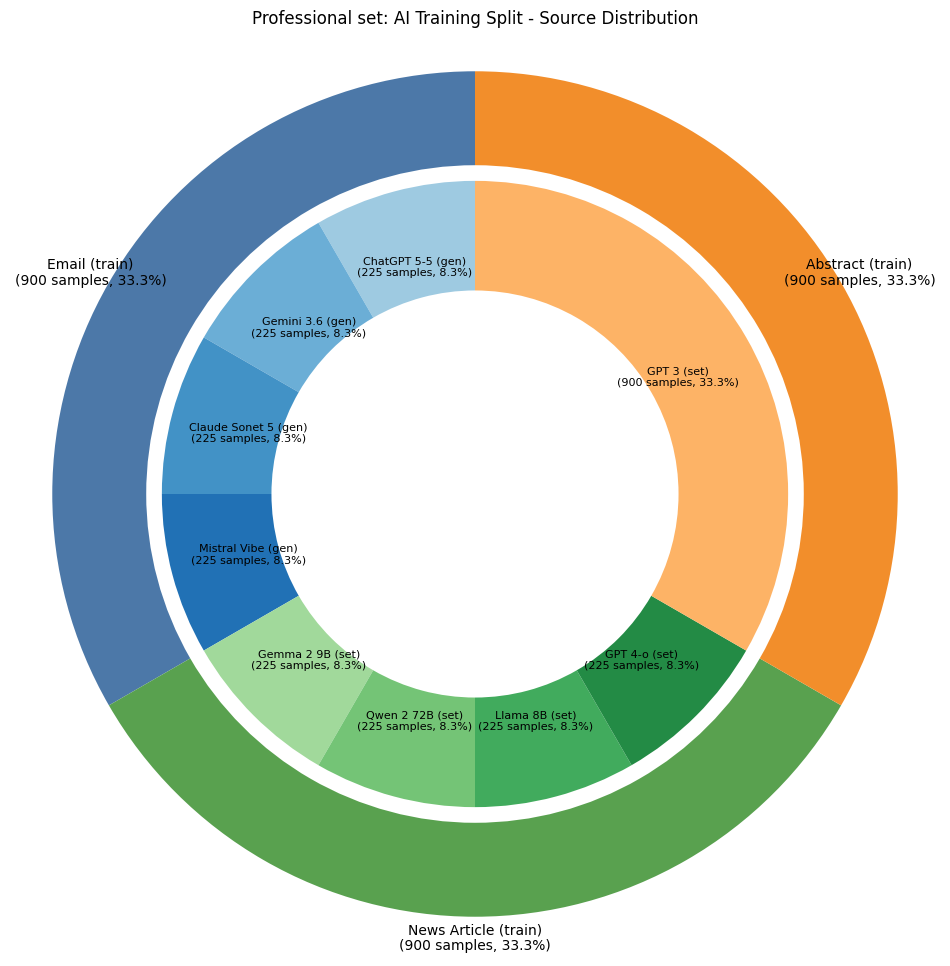

In [9]:
AItrainsplit_df = pd.DataFrame({
    'Category': [
        'ChatGPT 5-5 (gen)',
        'Gemini 3.6 (gen)',
        'Claude Sonet 5 (gen)',
        'Mistral Vibe (gen)',
        'Gemma 2 9B (set)',
        'Qwen 2 72B (set)',
        'Llama 8B (set)',
        'GPT 4-o (set)',
        'GPT 3 (set)'
    ],
    'Count': [
        225, 225, 225, 225,
        225, 225, 225, 225,
        900
    ]
})


# Total samples
total = AItrainsplit_df['Count'].sum()


inner_labels = [
    f"{category}\n({count} samples, {count/total*100:.1f}%)"
    for category, count in zip(
        AItrainsplit_df['Category'],
        AItrainsplit_df['Count']
    )
]

group_sizes = [
    AItrainsplit_df['Count'][0:4].sum(),  # Email
    AItrainsplit_df['Count'][4:8].sum(),  # News Article
    AItrainsplit_df['Count'][8:9].sum()   # Abstract
]

group_names = [
    'Email (train)',
    'News Article (train)',
    'Abstract (train)'
]


outer_labels = [
    f"{name}\n({size} samples, {size/sum(group_sizes)*100:.1f}%)"
    for name, size in zip(group_names, group_sizes)
]


outer_colors = [
    '#4C78A8',  # Email - blue
    '#59A14F',  # News - green
    '#F28E2B'   # Abstract - orange
]


inner_colors = [
    '#9ECAE1',
    '#6BAED6',
    '#4292C6',
    '#2171B5',

    '#A1D99B',
    '#74C476',
    '#41AB5D',
    '#238B45',

    '#FDB366'
]


fig, ax = plt.subplots(figsize=(12, 12))


# Inner ring
ax.pie(
    AItrainsplit_df['Count'],
    labels=inner_labels,
    radius=1,
    startangle=90,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 8
    }
)


# Outer ring
ax.pie(
    group_sizes,
    labels=outer_labels,
    radius=1.35,
    startangle=90,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center'
    }
)


plt.title("Professional set: AI Training Split - Source Distribution")
plt.axis('equal')
plt.show()

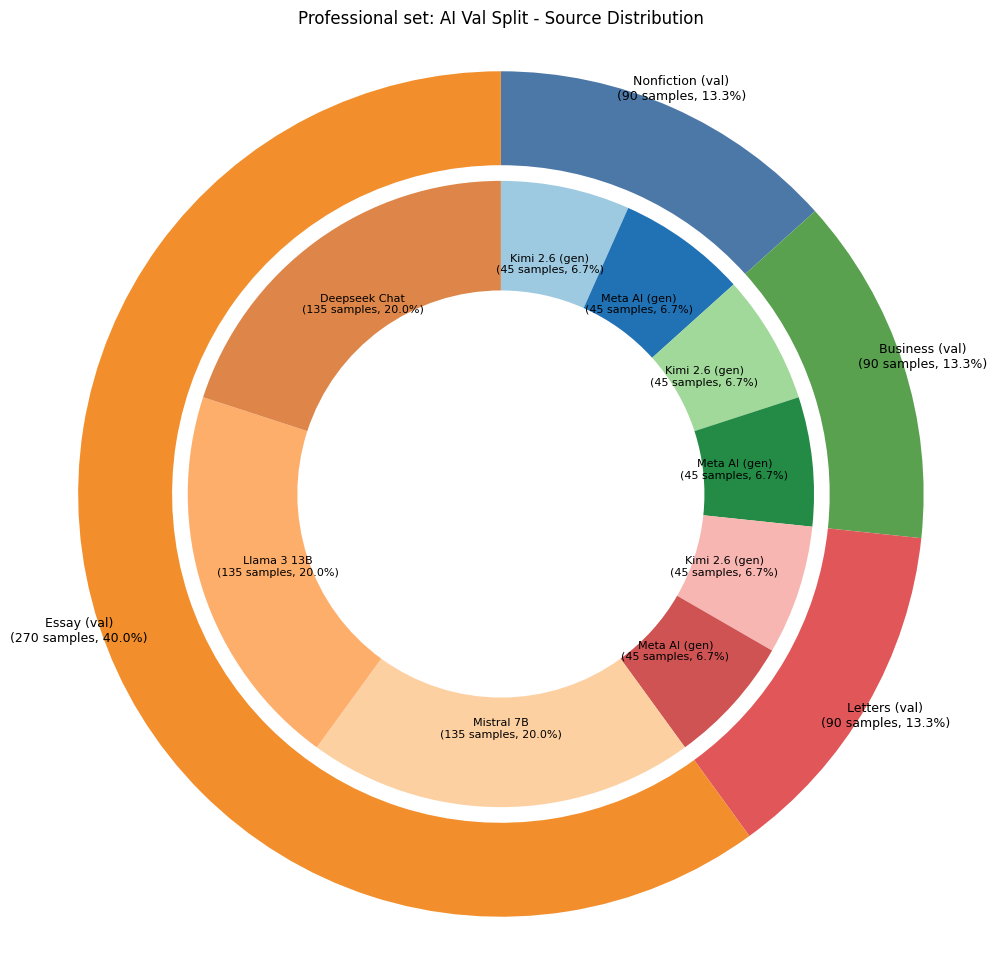

In [10]:
AIvalsplit_df = pd.DataFrame({
    'Category': [
        'Kimi 2.6 (gen)',
        'Mistral 7B Instruct (set)',
        'Llama 3 13B Instruct (set)',
        'Deepseek Chat (set)',
        'Meta AI (gen)'
    ],
    'Count': [
        135, 135, 135, 135, 135
    ]
})

inner_sizes = [
    # Nonfiction
    45, 45,

    # Business
    45, 45,

    # Letters
    45, 45,

    # Essay
    135, 135, 135
]

total = sum(inner_sizes)

inner_labels = [
    f"Kimi 2.6 (gen)\n(45 samples, {45/total*100:.1f}%)",
    f"Meta AI (gen)\n(45 samples, {45/total*100:.1f}%)",

    f"Kimi 2.6 (gen)\n(45 samples, {45/total*100:.1f}%)",
    f"Meta AI (gen)\n(45 samples, {45/total*100:.1f}%)",

    f"Kimi 2.6 (gen)\n(45 samples, {45/total*100:.1f}%)",
    f"Meta AI (gen)\n(45 samples, {45/total*100:.1f}%)",

    f"Mistral 7B\n(135 samples, {135/total*100:.1f}%)",
    f"Llama 3 13B\n(135 samples, {135/total*100:.1f}%)",
    f"Deepseek Chat\n(135 samples, {135/total*100:.1f}%)"
]

group_sizes = [
    90,   # Nonfiction
    90,   # Business
    90,   # Letters
    405   # Essay
]

group_total = sum(group_sizes)

group_labels = [
    f"Nonfiction (val)\n(90 samples, {90/group_total*100:.1f}%)",
    f"Business (val)\n(90 samples, {90/group_total*100:.1f}%)",
    f"Letters (val)\n(90 samples, {90/group_total*100:.1f}%)",
    f"Essay (val)\n(270 samples, {270/group_total*100:.1f}%)"
]

outer_colors = [
    '#4C78A8',  # Nonfiction
    '#59A14F',  # Business
    '#E15759',  # Letters
    '#F28E2B'   # Essay
]


inner_colors = [
    # Nonfiction shades
    '#9ECAE1',
    '#2171B5',

    # Business shades
    '#A1D99B',
    '#238B45',

    # Letters shades
    '#F7B6B2',
    '#CF5353',

    # Essay shades
    '#FDD0A2',
    '#FDAE6B',
    '#DE8649'
]

fig, ax = plt.subplots(figsize=(12, 12))

start_angle = 90


# Inner ring
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1,
    startangle=start_angle,
    counterclock=False,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 8
    }
)


# Outer ring
ax.pie(
    group_sizes,
    labels=group_labels,
    radius=1.35,
    startangle=start_angle,
    counterclock=False,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 9
    }
)


plt.title("Professional set: AI Val Split - Source Distribution")
plt.axis('equal')
plt.show()

### Casual set

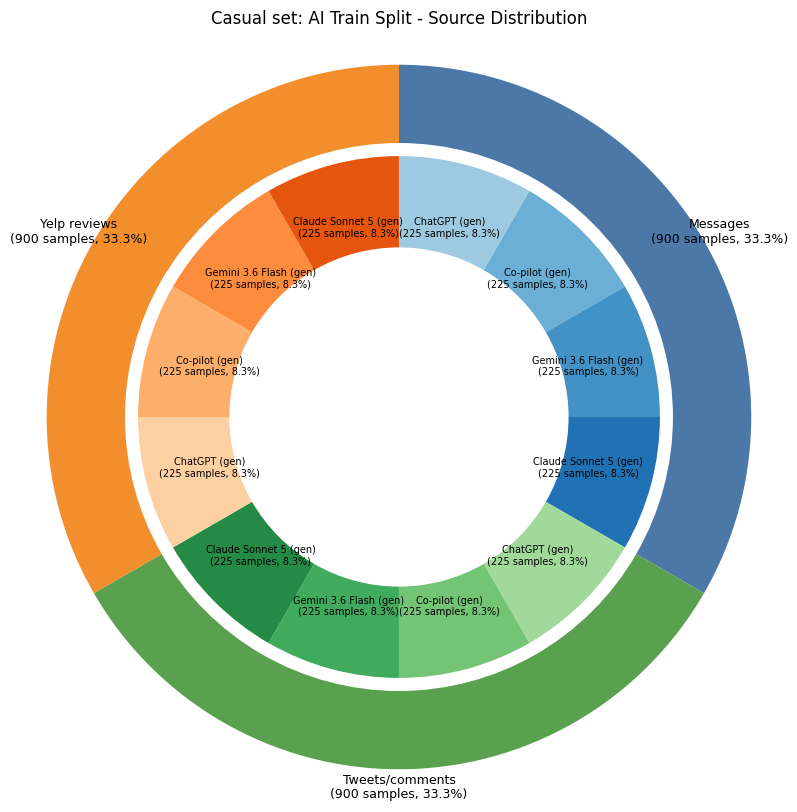

In [ ]:
AIvalsplit_df = pd.DataFrame({
    'Category': [
        'ChatGPT (gen)',
        'Co-pilot (gen)',
        'Gemini 3.6 Flash (gen)',
        'Claude Sonnet 5 (gen)',
    ],
    'Count': [675, 675, 675, 675]
})

inner_sizes = [
    # Messages
    225, 225, 225, 225,

    # Tweets/comments
    225, 225, 225, 225,

    # Yelp reviews
    225, 225, 225, 225,
]

total = sum(inner_sizes)


models = [
    'ChatGPT (gen)',
    'Co-pilot (gen)',
    'Gemini 3.6 Flash (gen)',
    'Claude Sonnet 5 (gen)'
]


inner_labels = []

for _ in range(3):
    for model in models:
        inner_labels.append(
            f"{model}\n(225 samples, {225/total*100:.1f}%)"
        )

group_sizes = [
    900,  # Messages
    900,  # Tweets/comments
    900   # Yelp reviews
]

group_total = sum(group_sizes)

group_labels = [
    f"Messages\n(900 samples, {900/group_total*100:.1f}%)",
    f"Tweets/comments\n(900 samples, {900/group_total*100:.1f}%)",
    f"Yelp reviews\n(900 samples, {900/group_total*100:.1f}%)"
]

outer_colors = [
    '#4C78A8',  # Messages - blue
    '#59A14F',  # Tweets/comments - green
    '#F28E2B'   # Yelp reviews - orange
]


inner_colors = [
    # Messages shades
    '#9ECAE1',
    '#6BAED6',
    '#4292C6',
    '#2171B5',

    # Tweets/comments shades
    '#A1D99B',
    '#74C476',
    '#41AB5D',
    '#238B45',

    # Yelp shades
    '#FDD0A2',
    '#FDAE6B',
    '#FD8D3C',
    '#E6550D'
]

fig, ax = plt.subplots(figsize=(10, 10))

start_angle = 90


# Inner ring (AI models)
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1,
    startangle=start_angle,
    counterclock=False,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 7
    }
)


# Outer ring (document groups)
ax.pie(
    group_sizes,
    labels=group_labels,
    radius=1.35,
    startangle=start_angle,
    counterclock=False,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 9
    }
)


plt.title("Casual set: AI Train Split - Source Distribution")
plt.axis('equal')
plt.show()

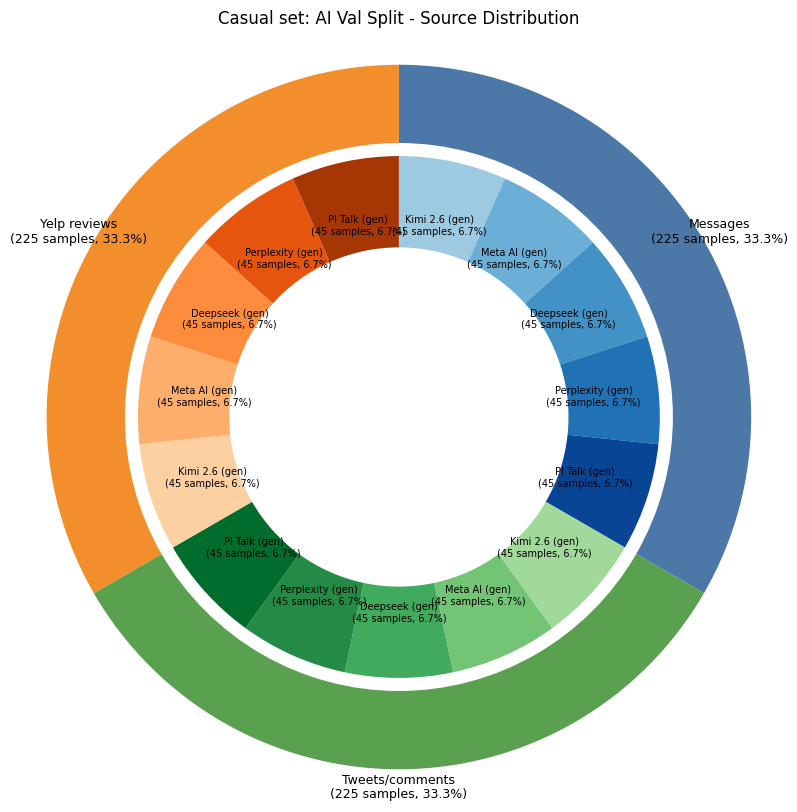

In [ ]:
AIvalsplit_df = pd.DataFrame({
    'Category': [
        'Kimi 2.6 (gen)',
        'Meta AI (gen)',
        'Deepseek (gen)',
        'Perplexity (gen)',
        'PI Talk (gen)'
    ],
    'Count': [135, 135, 135, 135, 135]
})

inner_sizes = [
    # Messages
    45, 45, 45, 45, 45,

    # Tweets/comments
    45, 45, 45, 45, 45,

    # Yelp reviews
    45, 45, 45, 45, 45
]

total = sum(inner_sizes)


models = [
    'Kimi 2.6 (gen)',
    'Meta AI (gen)',
    'Deepseek (gen)',
    'Perplexity (gen)',
    'PI Talk (gen)'
]

inner_labels = []

for _ in range(3):
    for model in models:
        inner_labels.append(
            f"{model}\n(45 samples, {45/total*100:.1f}%)"
        )

group_sizes = [
    225,  # Messages
    225,  # Tweets/comments
    225   # Yelp reviews
]

group_total = sum(group_sizes)

group_labels = [
    f"Messages\n(225 samples, {225/group_total*100:.1f}%)",
    f"Tweets/comments\n(225 samples, {225/group_total*100:.1f}%)",
    f"Yelp reviews\n(225 samples, {225/group_total*100:.1f}%)"
]

# Outer group colors
outer_colors = [
    '#4C78A8',  # Messages - blue
    '#59A14F',  # Tweets/comments - green
    '#F28E2B'   # Yelp reviews - orange
]


# Inner shades
inner_colors = [
    # Messages shades
    '#9ECAE1',
    '#6BAED6',
    '#4292C6',
    '#2171B5',
    '#084594',

    # Tweets/comments shades
    '#A1D99B',
    '#74C476',
    '#41AB5D',
    '#238B45',
    '#006D2C',

    # Yelp shades
    '#FDD0A2',
    '#FDAE6B',
    '#FD8D3C',
    '#E6550D',
    '#A63603'
]

fig, ax = plt.subplots(figsize=(10, 10))

start_angle = 90


# Inner ring (AI models)
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1,
    startangle=start_angle,
    counterclock=False,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 7
    }
)


# Outer ring (document groups)
ax.pie(
    group_sizes,
    labels=group_labels,
    radius=1.35,
    startangle=start_angle,
    counterclock=False,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 9
    }
)


plt.title("Casual set: AI Val Split - Source Distribution")
plt.axis('equal')
plt.show()

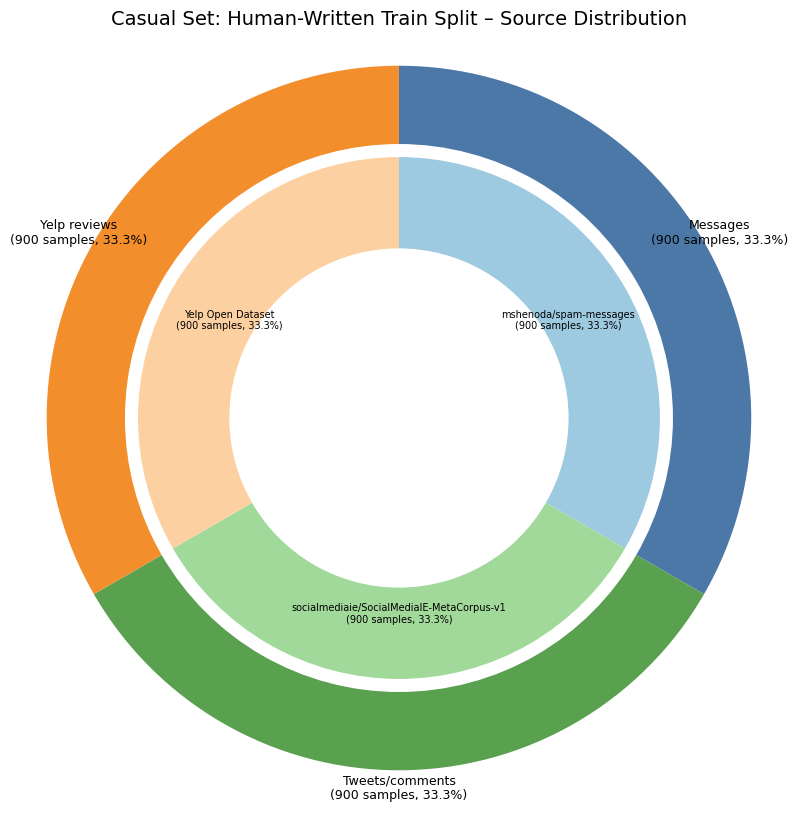

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

Humanvalsplit_df = pd.DataFrame({
    'Category': [
        'mshenoda/spam-messages',
        'socialmediaie/SocialMediaIE-MetaCorpus-v1',
        'Yelp Open Dataset'
    ],
    'Count': [900, 900, 900]
})

inner_sizes = [
    900,  # Messages
    900,  # Tweets/comments
    900   # Yelp reviews
]

total = sum(inner_sizes)

models = [
    'mshenoda/spam-messages',
    'socialmediaie/SocialMediaIE-MetaCorpus-v1',
    'Yelp Open Dataset'
]

inner_labels = [
    f"{model}\n(900 samples, {900/total*100:.1f}%)"
    for model in models
]

group_sizes = [
    900,  # Messages
    900,  # Tweets/comments
    900   # Yelp reviews
]

group_total = sum(group_sizes)

group_labels = [
    f"Messages\n(900 samples, {900/group_total*100:.1f}%)",
    f"Tweets/comments\n(900 samples, {900/group_total*100:.1f}%)",
    f"Yelp reviews\n(900 samples, {900/group_total*100:.1f}%)"
]

outer_colors = [
    '#4C78A8',  # Messages
    '#59A14F',  # Tweets/comments
    '#F28E2B'   # Yelp reviews
]

inner_colors = [
    '#9ECAE1',  # Messages
    '#A1D99B',  # Tweets/comments
    '#FDD0A2'   # Yelp reviews
]

fig, ax = plt.subplots(figsize=(10, 10))

start_angle = 90

# Inner ring
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1,
    startangle=start_angle,
    counterclock=False,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 7
    }
)

# Outer ring
ax.pie(
    group_sizes,
    labels=group_labels,
    radius=1.35,
    startangle=start_angle,
    counterclock=False,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 9
    }
)

plt.title(
    "Casual Set: Human-Written Train Split – Source Distribution",
    fontsize=14
)

plt.axis('equal')
plt.show()

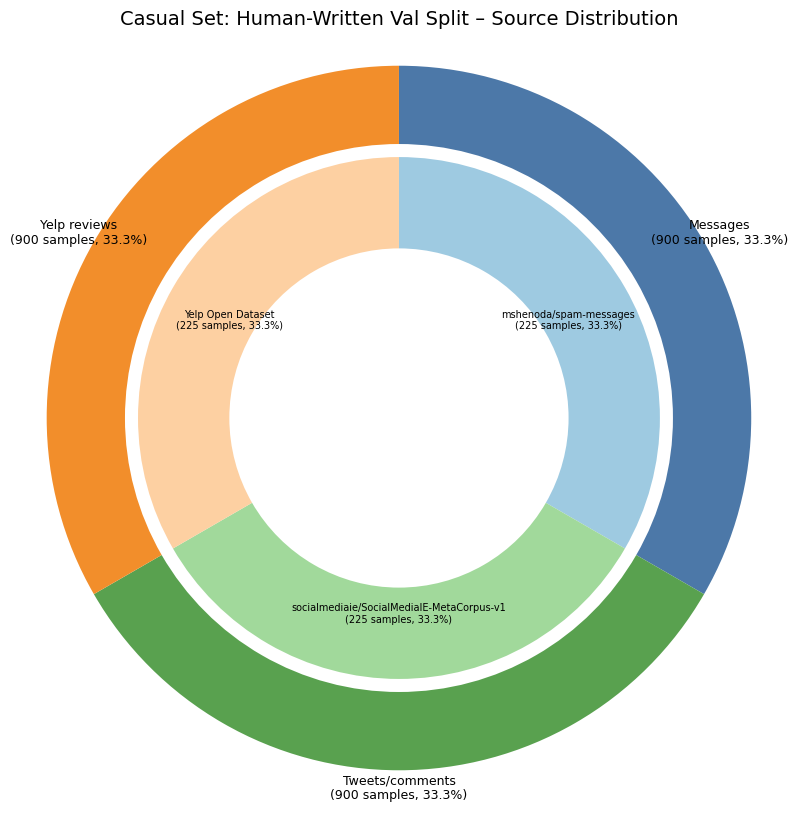

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

Humanvalsplit_df = pd.DataFrame({
    'Category': [
        'mshenoda/spam-messages',
        'socialmediaie/SocialMediaIE-MetaCorpus-v1',
        'Yelp Open Dataset'
    ],
    'Count': [225, 225, 225]
})

inner_sizes = [
    225,  # Messages
    225,  # Tweets/comments
    225   # Yelp reviews
]

total = sum(inner_sizes)

models = [
    'mshenoda/spam-messages',
    'socialmediaie/SocialMediaIE-MetaCorpus-v1',
    'Yelp Open Dataset'
]

inner_labels = [
    f"{model}\n(225 samples, {225/total*100:.1f}%)"
    for model in models
]

group_sizes = [
    225,  # Messages
    225,  # Tweets/comments
    225   # Yelp reviews
]

group_total = sum(group_sizes)

group_labels = [
    f"Messages\n(900 samples, {225/group_total*100:.1f}%)",
    f"Tweets/comments\n(900 samples, {225/group_total*100:.1f}%)",
    f"Yelp reviews\n(900 samples, {225/group_total*100:.1f}%)"
]

outer_colors = [
    '#4C78A8',  # Messages
    '#59A14F',  # Tweets/comments
    '#F28E2B'   # Yelp reviews
]

inner_colors = [
    '#9ECAE1',  # Messages
    '#A1D99B',  # Tweets/comments
    '#FDD0A2'   # Yelp reviews
]

fig, ax = plt.subplots(figsize=(10, 10))

start_angle = 90

# Inner ring
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1,
    startangle=start_angle,
    counterclock=False,
    labeldistance=0.75,
    colors=inner_colors,
    wedgeprops=dict(width=0.35),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 7
    }
)

# Outer ring
ax.pie(
    group_sizes,
    labels=group_labels,
    radius=1.35,
    startangle=start_angle,
    counterclock=False,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3),
    textprops={
        'ha': 'center',
        'multialignment': 'center',
        'fontsize': 9
    }
)

plt.title(
    "Casual Set: Human-Written Val Split – Source Distribution",
    fontsize=14
)

plt.axis('equal')
plt.show()